# Lab work #1
# Ivan Mihun
# Group No 32

## Task 1: Data Cleaning and Preparation
**Objective:** Clean and prepare a dataset for analysis.

**Instructions:**
1. Load a dataset of your choice (from proposed Datasets).
2. Handle missing values by either removing them or imputing with appropriate values.
3. Remove any duplicate rows.
4. Convert categorical variables into numerical format using techniques like one-hot encoding (but be aware of sparse and non-sparse one-hot encoding).
5. Normalize or standardize numerical features.
6. Save the cleaned dataset to a new CSV file.

In [4]:
import pandas as pd

df = pd.read_csv(f"car_price_dataset.csv")

df.head()

,Brand,Model,Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Price
0,Kia,Rio,2020,4.2,Diesel,Manual,289944,3,5,8501
1,Chevrolet,Malibu,2012,2.0,Hybrid,Automatic,5356,2,3,12092
2,Mercedes,GLA,2020,4.2,Diesel,Automatic,231440,4,2,11171
3,Audi,Q5,2023,2.0,Electric,Manual,160971,2,1,11780
4,Volkswagen,Golf,2003,2.6,Hybrid,Semi-Automatic,286618,3,3,2867


In [5]:
df.isna().sum()

Brand           0
Model           0
Year            0
Engine_Size     0
Fuel_Type       0
Transmission    0
Mileage         0
Doors           0
Owner_Count     0
Price           0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
categorical_cols = df.select_dtypes(include=["object", "category"]).columns

df[categorical_cols] = df[categorical_cols].astype("category").apply(lambda x: x.cat.codes)

df.head()

,Brand,Model,Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Price
0,6,24,2020,4.2,0,1,289944,3,5,8501
1,2,19,2012,2.0,2,0,5356,2,3,12092
2,7,16,2020,4.2,0,0,231440,4,2,11171
3,0,22,2023,2.0,1,1,160971,2,1,11780
4,9,17,2003,2.6,2,2,286618,3,3,2867


In [8]:
df.to_csv("cleaned_car_price_dataset.csv", index=False)

## Task 2: Exploratory Data Analysis (EDA)
**Objective:** Perform exploratory data analysis to understand the dataset.

**Instructions:**
1. Use the cleaned dataset from Task 1.
2. Calculate basic statistics (mean, median, mode, standard deviation) for numerical features.
3. Visualize the distribution of numerical features using histograms and box plots.
4. Create scatter plots to visualize relationships between pairs of numerical features.
5. Use Seaborn to create a pair plot or heatmap to visualize correlations between features.
6. Summarize your findings in a short report.

In [22]:
numerical_df = df.drop(columns=categorical_cols)

In [10]:
numerical_df.describe()

,Year,Engine_Size,Mileage,Doors,Owner_Count,Price
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,2011.543700,3.000560,149239.111800,3.497100,2.991100,8852.96440
std,6.897699,1.149324,86322.348957,1.110097,1.422682,3112.59681
min,2000.000000,1.000000,25.000000,2.000000,1.000000,2000.00000
25%,2006.000000,2.000000,74649.250000,3.000000,2.000000,6646.00000
50%,2012.000000,3.000000,149587.000000,3.000000,3.000000,8858.50000
75%,2017.000000,4.000000,223577.500000,4.000000,4.000000,11086.50000
max,2023.000000,5.000000,299947.000000,5.000000,5.000000,18301.00000


array([[<Axes: title={'center': 'Year'}>,
        <Axes: title={'center': 'Engine_Size'}>],
       [<Axes: title={'center': 'Mileage'}>,
        <Axes: title={'center': 'Doors'}>],
       [<Axes: title={'center': 'Owner_Count'}>,
        <Axes: title={'center': 'Price'}>]], dtype=object)

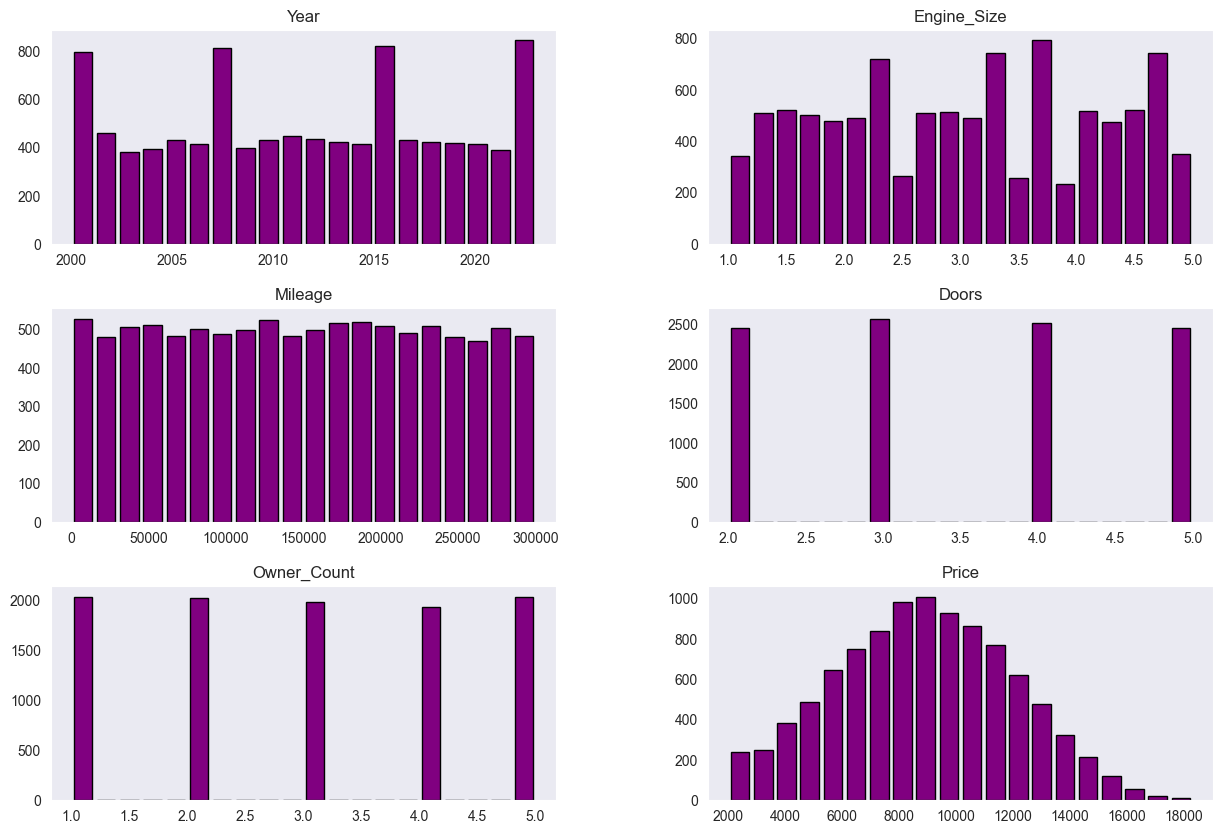

In [11]:
numerical_df.hist(rwidth=0.8,
                  bins=20,
                  edgecolor='black',
                  grid=False,
                  color="purple",
                  figsize=(15, 10))


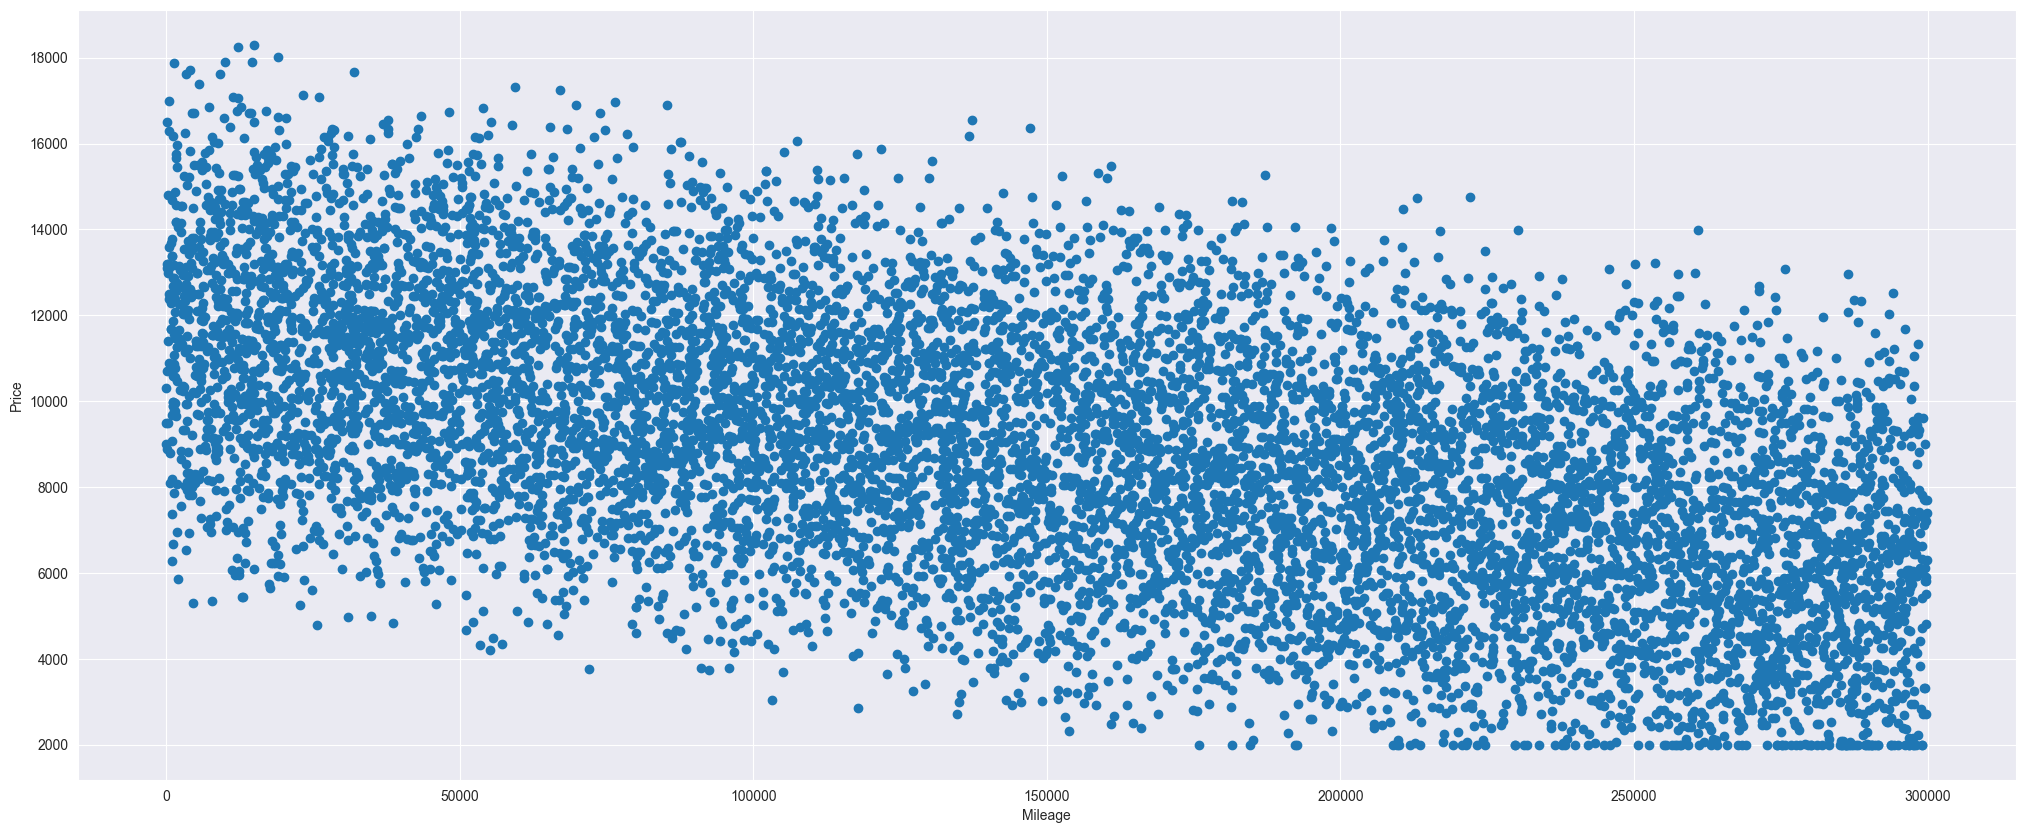

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(25, 10))
plt.xlabel("Mileage")
plt.ylabel("Price")
plt.scatter(x=numerical_df["Mileage"],
            y=numerical_df["Price"])

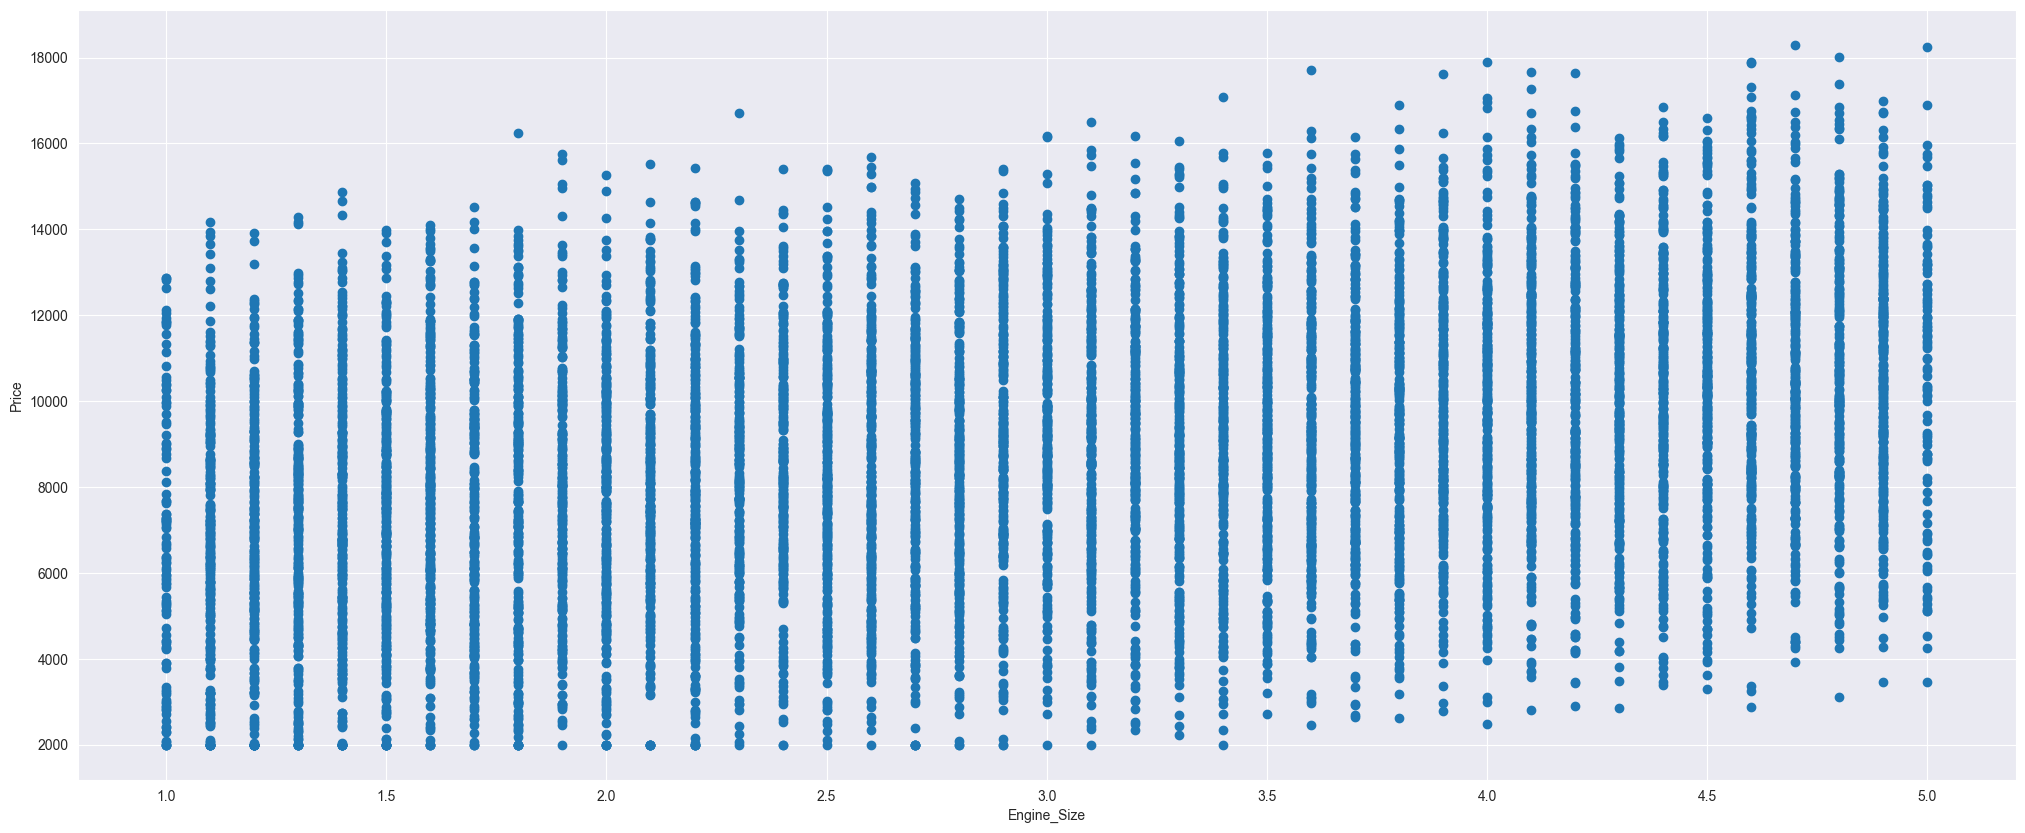

In [13]:
plt.figure(figsize=(25, 10))
plt.xlabel("Engine_Size")
plt.ylabel("Price")
plt.scatter(x=numerical_df["Engine_Size"],
            y=numerical_df["Price"])

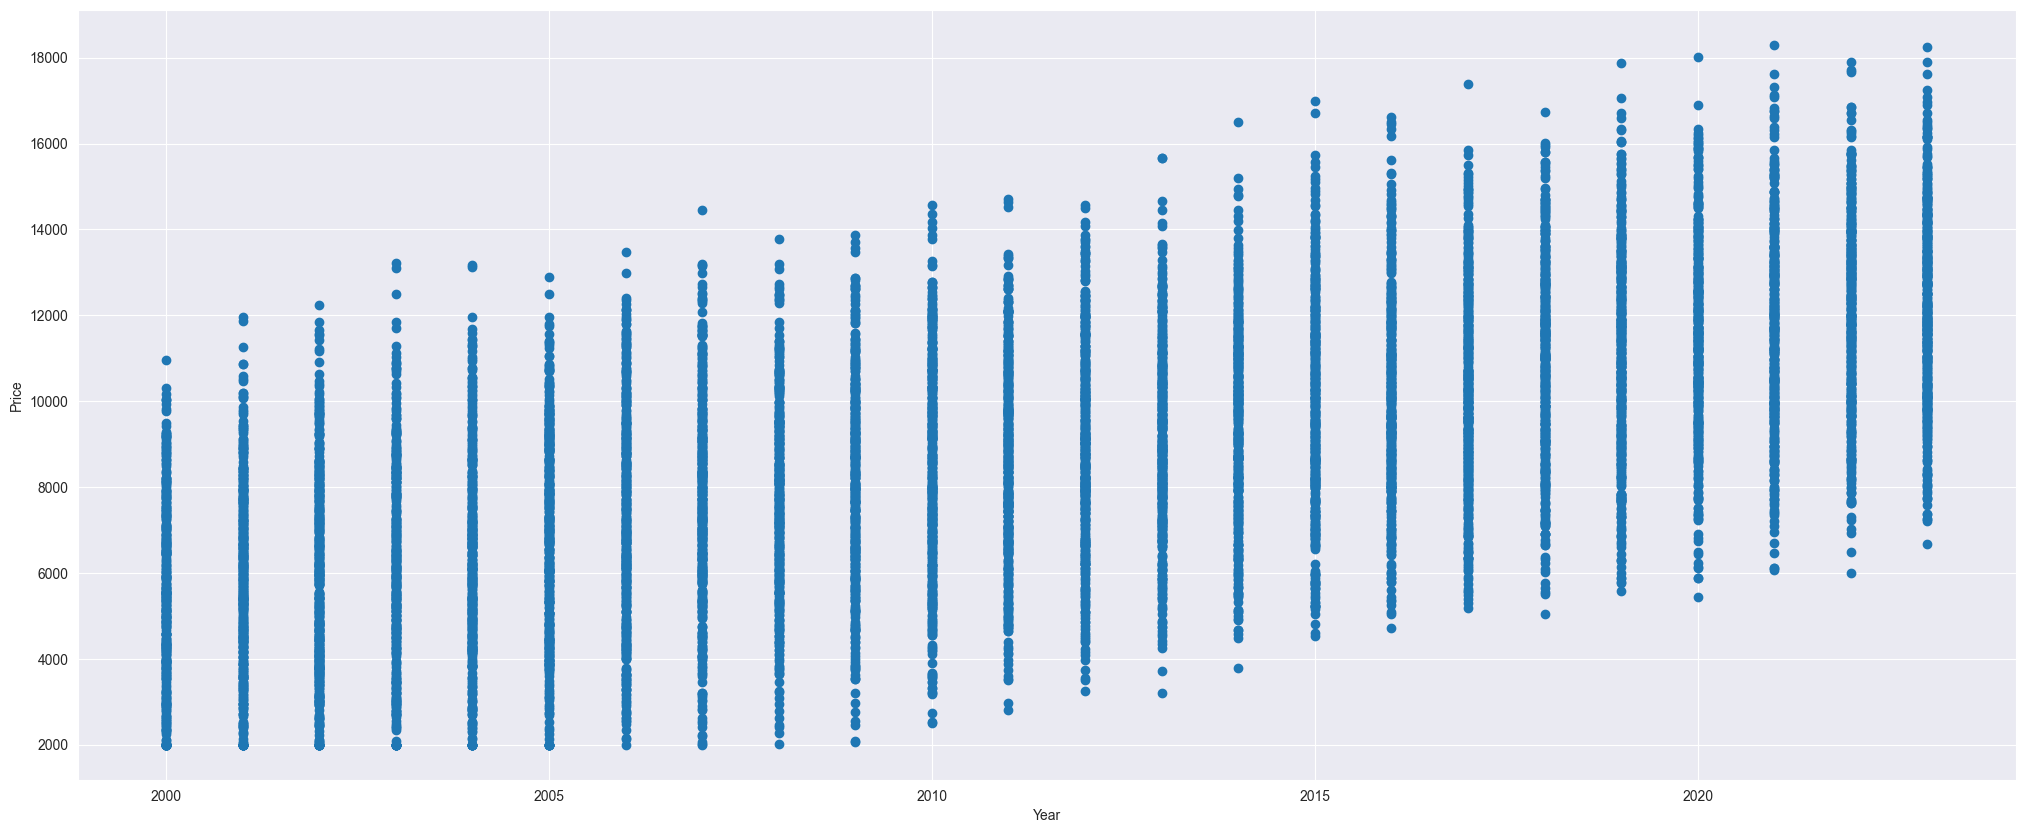

In [14]:
plt.figure(figsize=(25, 10))
plt.xlabel("Year")
plt.ylabel("Price")
plt.scatter(x=numerical_df["Year"],
            y=numerical_df["Price"])

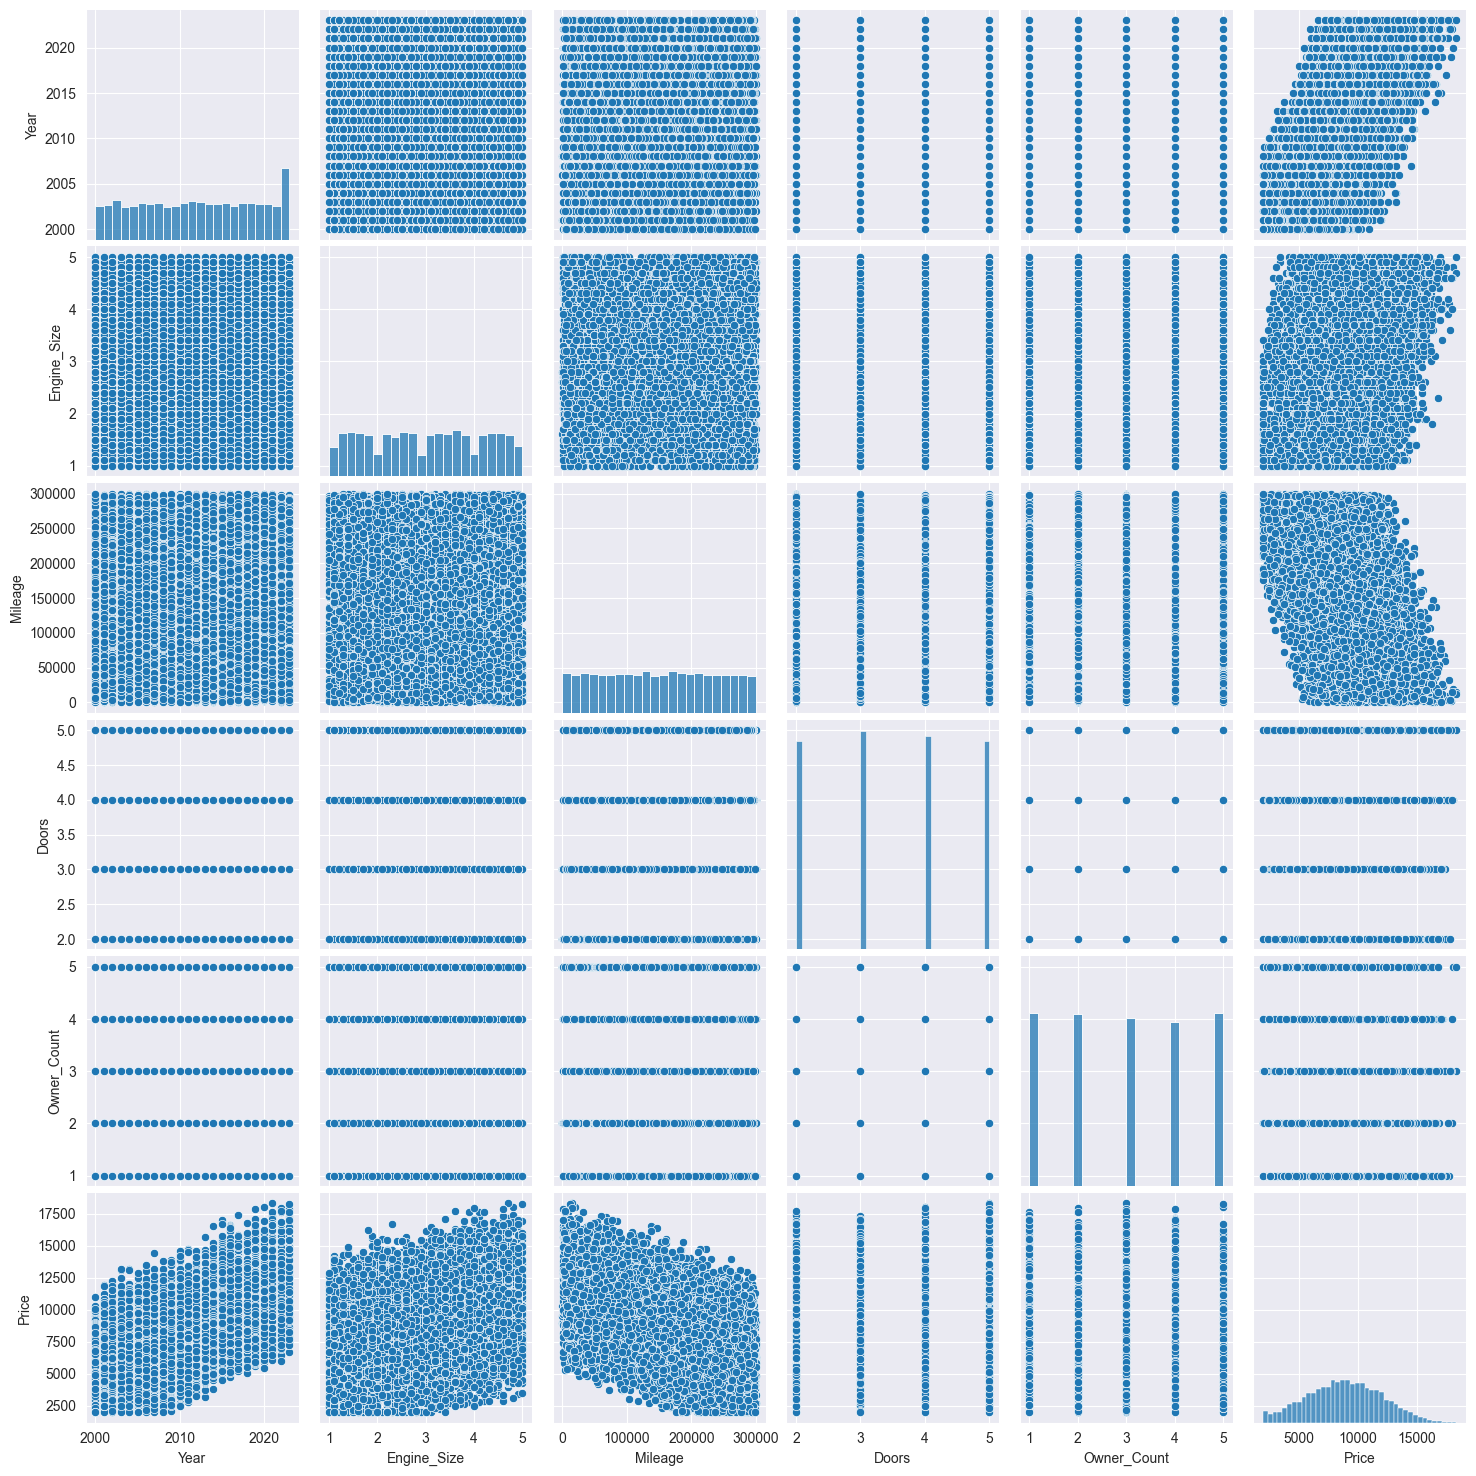

In [15]:
import seaborn as sns

sns.pairplot(numerical_df)

<Axes: >

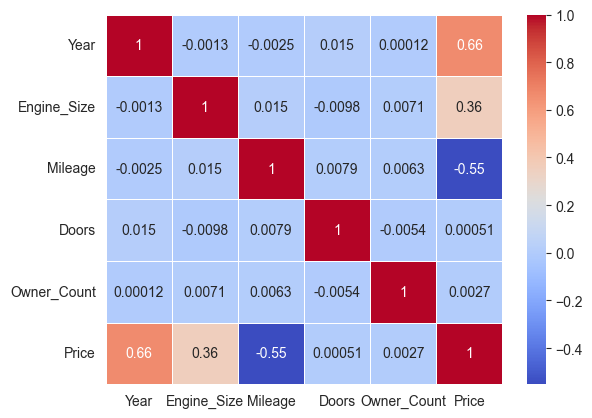

In [16]:
sns.heatmap(numerical_df.corr(), annot=True, cmap="coolwarm", linewidths=0.5)

## Task 2: Summary

**Correlation:**

As clearly illustrated by the heatmap, and to a lesser extent by the pairplot, there is a pretty strong positive correlation between the Price and the Year, and a bit weaker between the Price and Engine_Size. This indicates that as the Year or Engine_Size increases, the Price also tends to increase. As for the Mileage, it is quite strongly correlated with the Price but the correlation is negative, meaning that the Price tends to increase as the Mileage decreases.



 ## Task 3: Feature Engineering
**Objective:** Create new features to improve the dataset's predictive power.

**Instructions:**
1. Use the cleaned dataset from Task 1.
2. Create new features based on existing ones (e.g., age groups, interaction terms).
3. Use domain knowledge to generate meaningful features.
4. Analyze the impact of the new features on the dataset's distribution and correlations.
5. Visualize the new features using appropriate plots.

In [ ]:
df["Car_Age"] = 2024 - df["Year"]

df["Car_Age_Group"] = pd.cut(df["Car_Age"], bins=[0, 3, 10, 20, 100], labels=[1, 2, 3, 4])

df["Mileage_per_Year"] = df["Mileage"] / df["Car_Age"].replace(0, 1)

df.head()

In [ ]:
plt.figure(figsize=(25, 10))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", linewidths=0.5)

In [ ]:
plt.xlabel("Mileage_per_Year")
plt.ylabel("Number of Cars")
df["Mileage_per_Year"].hist(bins=20, edgecolor="white", grid=False, color="purple", figsize=(16, 8))

## Task 4: Data Visualization
**Objective:** Create insightful visualizations to communicate findings.

**Instructions:**
1. Use the dataset with new features from Task 3.
2. Create a bar chart to compare categorical features.
3. Use a line plot to show trends over time (if applicable).
4. Create a heatmap to visualize correlations between features.
5. Use Seaborn to create a violin plot or swarm plot to compare distributions across categories.
6. Combine multiple plots into a single figure using Matplotlib's subplot functionality.

<Axes: xlabel='Model', ylabel='Price'>

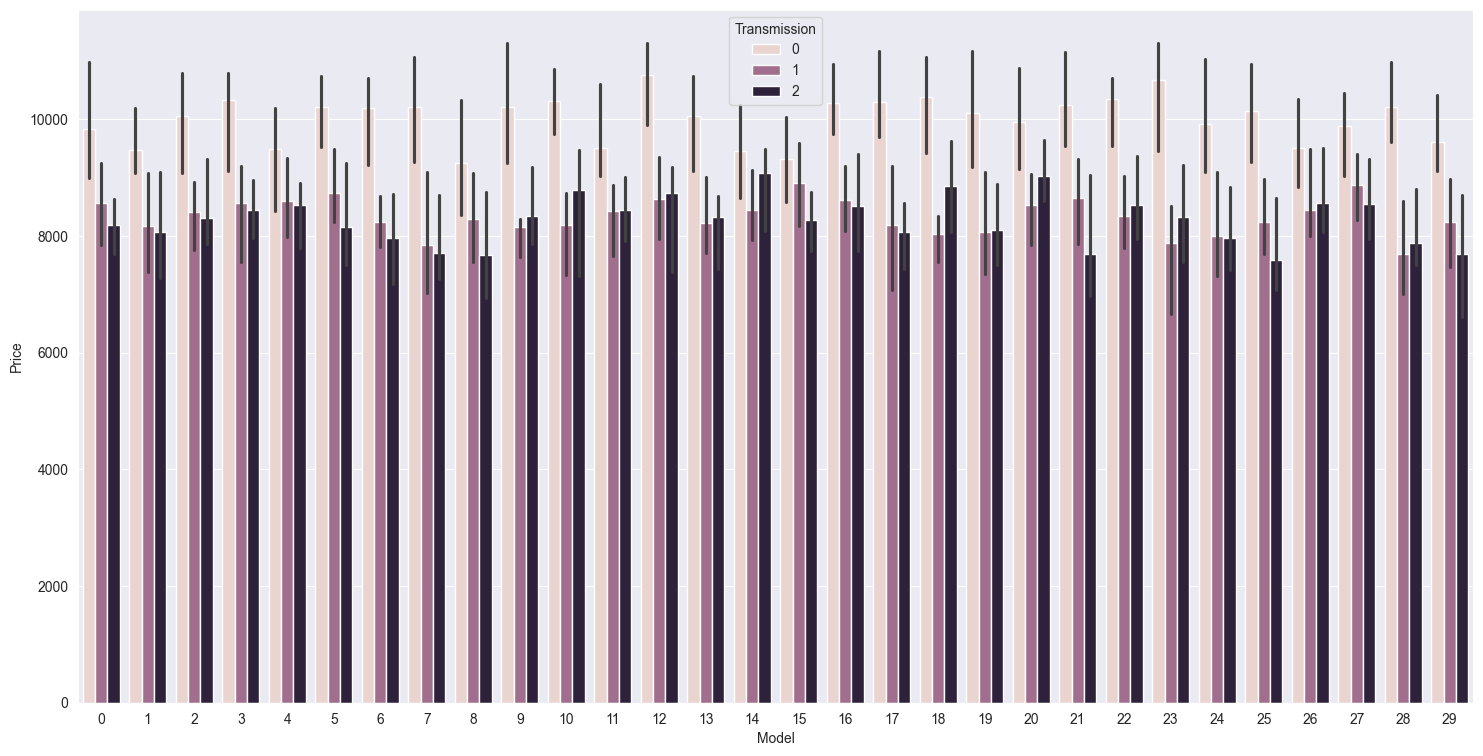

<Axes: xlabel='Car_Age_Group', ylabel='Price'>

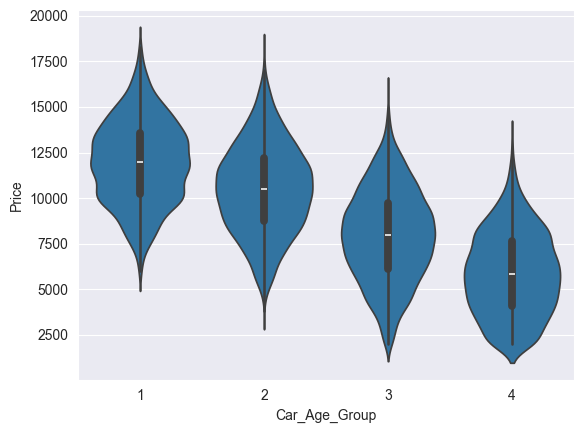